In [4]:
%matplotlib qt
%reload_ext autoreload
%autoreload 2
import plotter
import pl_init
import pl_spec
import sgd


In [90]:
# Initialization
pl_init.pl_init()
sgd.sgd_init()

# Note for Shuhul: was having an issue with the labeling of the shared session, 
# I think it's fixed now but I hope I didn't mess anything else up
# The command window would pop up with an error saying the name "MySharedSession" was taken, 
# then give a new default name, but the code was still searching for "MySharedSession"

Launching matlab...
Waiting for MATLAB session (up to 10s)...


Waiting:  30%|███       | 3/10 [00:04<00:09,  1.34s/sec]


Establishing shared session ('MATLAB_23740')...
Session registered as 'MATLAB_23740' (not 'MySharedSession'); updating shared state.
Done connecting!


<'USBInstrument'('USB0::0xF4ED::0xEE3A::SDG10GAD1R1771::0::INSTR')>

In [5]:
# Reconnect to an already-running MATLAB + LightField session (use this instead of the init cell above)
import matlab.engine
import _matlab_session

sessions = matlab.engine.find_matlab()
print(f'Available sessions: {sessions}')

if not sessions:
    print('No MATLAB sessions found — run the init cell above to launch one.')
else:
    name = 'MySharedSession' if 'MySharedSession' in sessions else sessions[0]
    _matlab_session.name = name
    eng = matlab.engine.connect_matlab(name)
    eng.addpath(__import__('os').path.join(__import__('os').getcwd(), 'matlab'), nargout=0)
    eng.pl_setup(nargout=0)
    print(f"Connected to '{name}'  ✓")

sgd.sgd_init()

Available sessions: ('MATLAB_23740',)
Connected to 'MATLAB_23740'  ✓
Scanning for instruments...
Getting ready...
Ready for use!


## Filter & Rotation Stage

Controls for the bandpass filter flip mount (MFF101) and rotation stage (KDC101).

- **flip_down**: inserts the bandpass filter into the beam path
- **flip_up**: removes the filter (open path)
- **rotation_move**: rotates the filter to a target angle (degrees)

In [7]:
import filter

# Initialize both devices (run once per session)
filter.filter_init()
filter.filter_on()

Building device list for filter...
Connecting to Filter Flipper (Serial: 37010764)...


DeviceNotReadyException: Device is not connected
   at Thorlabs.MotionControl.DeviceManagerCLI.ThorlabsGenericCoreDeviceCLI.VerifyDeviceConnected(Int32 functionDepth)
   at Thorlabs.MotionControl.GenericMotorCLI.GenericMotorCLI.Connect(String serialNo)

### Flip Mount

In [ ]:
# Remove filter from beam
filter.flip_down()

In [ ]:
# Insert filter into beam
filter.flip_up()

### Rotation Stage

In [ ]:
# Home the rotation stage (run after init)
filter.rotation_home()

In [ ]:
# Move to target angle (degrees)
target_angle = 0.0
filter.rotation_move(target_angle)

### Filter Test Sequence

Run the cell below to step through flip and rotation in one go — watch the hardware between each step.

In [ ]:
import time
import numpy as np

PAUSE      = 2   # seconds between steps
CAL_FOLDER = '2026-04-07_14-48-20'

# Load calibration and pick ~6 evenly spaced wavelengths across the range
table  = np.load(f'calibration/{CAL_FOLDER}/calibration_table.npy')
valid  = table[~np.isnan(table[:, 1])]
wls    = np.linspace(valid[:, 1].min(), valid[:, 1].max(), 6)
angles = [float(valid[np.argmin(np.abs(valid[:, 1] - w)), 0]) for w in wls]

print(f'Calibration range: {valid[:,1].min():.1f} – {valid[:,1].max():.1f} nm')
print(f'{"Step":<6} {"Wavelength":>12}  {"Angle":>8}')
for i, (w, a) in enumerate(zip(wls, angles), 1):
    print(f'{i:<6} {w:>10.1f} nm  {a:>6.1f} deg')

print()
for i, (w, a) in enumerate(zip(wls, angles), 1):
    print(f'Step {i}: moving to {a:.1f} deg  ({w:.1f} nm)')
    filter.rotation_move(a)
    time.sleep(PAUSE)

print('Done.')

### Shutdown

In [ ]:
# Disconnect devices cleanly at end of session
filter.filter_off()

## Parameters

| Parameter            | Type   | Description |
|---------------------|--------|-------------|
| `xdim`              | float  | Total width of the scan area. Set to `0` for a single-point scan. |
| `ydim`              | float  | Total height of the scan area. Set to `0` for a single-point scan. |
| `dx`                | float  | Step size in the x direction. |
| `dy`                | float  | Step size in the y direction. |
| `center`            | tuple  | `(x, y)` coordinates for the center of the scan map. Default is `(0, 0)`. |
| `grating`           | int    | Spectrometer grating lines. Options: `150` (150 g/mm) or `600` (600 g/mm). |
| `exposure_time`     | float  | Integration time for the spectrometer in seconds. |
| `center_wavelength` | int    | Spectrometer center wavelength in nanometers (nm). |
| `classification_threshold` | float | Minimum fraction of the laser peak that emitter peak should be |
| `foldername`        | str    | Base name of the folder where data will be saved. |
| `scan_type`         | str    | Subfolder category for data organization. Options: `"coarse"` or `"fine"`. |
| `current_user`      | str    | User to receive Telegram alerts if the sample falls out of focus. Options: `"shuhul"`, `"kristina"`, or `"holland"`. |
| `data_folder`       | str    | Root directory for all saved data. Default is `"data"`. |

In [97]:
foldername = '20260512-PLSPC-PhENOM-Ch23-f011o015-f1a1-500uW-3s-1'
scan_type = 'coarse'
pl_spec.pl_spec_manual(
    xdim=30, ydim=30, dx=0.5, dy=0.5, center=(0,0), 
    grating=150, 
    exposure_time=3,
    center_wavelength=700,
    #classification_threshold=0.5,
    foldername=foldername, 
    scan_type=scan_type,
    current_user='holland'
)
plotter.plot_heatmap_manual(foldername, scan_type)

Connecting to matlab...
Getting wavelengths and setting up...
Starting scan...
Sgd on!


Acquiring x=15.00, y=15.00: 100%|██████████| 3721/3721 [3:44:15<00:00,  3.62s/it]   


Sgd off!
Scan complete, classifying data...
Found 20 distinct emitters.
Classification complete!
[WARNING] Scan completed, but focus was lost during acquisition.


Exception ignored in: <function MatlabEngine.__del__ at 0x000001D05C381A20>
Traceback (most recent call last):
  File "c:\Users\Public\Shared Confocal Files\SPE_Automation\.venv\lib\site-packages\matlab\engine\matlabengine.py", line 250, in __del__
    self.exit()
  File "c:\Users\Public\Shared Confocal Files\SPE_Automation\.venv\lib\site-packages\matlab\engine\matlabengine.py", line 232, in exit
    pythonengine.closeMATLAB(self.__dict__["_matlab"])
SystemError: MATLAB process cannot be terminated.


In [6]:
# Long scan at classified emitter x=-4.5, y=-11.0
# Generates test data for validating the bandpass alignment logic
foldername = '20260512-PLSPC-PhENOM-Ch23-f011o015-f1a1-500uW-3s-1'
scan_type  = 'long_x-4.5_y-11.0'

pl_spec.pl_spec_manual(
    xdim=0, ydim=0, dx=0, dy=0,
    center=(-4.5, -11.0),
    grating=600,
    exposure_time=10,
    center_wavelength=700,
    foldername=foldername,
    scan_type=scan_type,
    current_user='shuhul',
)

Connecting to matlab...


EngineError: Unable to connect to MATLAB session 'MATLAB_23740'.

In [ ]:
# Test find_emission_fwhm_center on the saved long scan test dataset — no hardware needed
import numpy as np
import matplotlib.pyplot as plt
from main import find_emission_fwhm_center, _bandpass_slope, angle_for_wavelength

LONG_SCAN = 'test_data/long_x-10.5_y-10.5'
CAL       = '2026-04-07_14-48-20'

out      = np.load(f'{LONG_SCAN}/out.npy')
wl       = np.load(f'{LONG_SCAN}/wl.npy')
spectrum = out[0, 0, :]

target_wl = find_emission_fwhm_center(spectrum, wl)
angle     = angle_for_wavelength(CAL, target_wl)
slope     = _bandpass_slope(CAL, target_wl)
print(f'FWHM centre : {target_wl:.2f} nm')
print(f'Cal angle   : {angle:.2f} deg')
print(f'Slope       : {slope:.3f} deg/nm')

# Plot
mask        = wl > 560
peak_height = float(spectrum[mask].max())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(wl, spectrum, lw=1, label='spectrum')
ax.axvline(target_wl, color='r',      ls='--', lw=1.5, label=f'FWHM centre: {target_wl:.1f} nm')
ax.axhline(peak_height / 2, color='orange', ls=':', lw=1, label='half max')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity (counts)')
ax.set_title('Test dataset — long scan x=-10.5, y=-10.5')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
import importlib
importlib.reload(plotter)

foldername = '20260414-PLSPC-PhENOM-Ch21-f009o009-e1-500uW-6s-postExp2a-2'
scan_type = 'coarse'
plotter.plot_heatmap_manual(foldername, scan_type)



In [51]:
# Course map
foldername='20260331-FinePLSPC-PhENOMCh21-f009o009-500uW-1.5s-e1-3'
pl_spec.pl_spec(xdim=3, ydim=3, dx=0.25, dy=0.25, center=(0,1.5), scan_type='course', exposure_time=2, center_wavelength=700, foldername=foldername, current_user='shuhul')

# instance1.set(PrincetonInstruments.LightField.AddIns.SpectrometerSettings.Grating, "[800nm,150][2][0]");
# instance1.set(PrincetonInstruments.LightField.AddIns.SpectrometerSettings.GratingCenterWavelength, 660)
# [500nm,600][1][0]

Connecting to matlab...
Getting wavelengths and setting up...
Starting scan...
Sgd on!


Scanning:   0%|          | 0/169 [00:00<?, ?it/s]

Moving to (-1.5 um, 0.0 um)
Done moving!


Scanning:   0%|          | 0/169 [00:14<?, ?it/s]

the MATLAB function has been cancelled


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
# Fine map
foldername='20260330-FinePLSPC-test-400uW-1.5s-e1-2'
pl_spec.pl_spec(xdim=2, ydim=2, dx=0.2, dy=0.1, exposure_time=1.5, scan_type='fine', foldername=foldername, current_user='kristina', center=(0, 1.5))

In [20]:
# Plot processing
foldername='20260425-PLSPC-PhENOM-Ch22-f017o008-500uW-2s-40um'
# foldername='20251124-PLSPC-PhENOM-Ch10-f010o007-200uw-1000ms-test-all'
plotter.plot_heatmap_manual(foldername, scan_type='coarse', slideshow_interval=0.5)

In [95]:
# Goto
sgd.goto(-15, -15)

Sgd on!
Moving to (-15 um, -15 um)
Done moving!


In [96]:
# End goto
sgd.home()

Moving to (0 um, 0 um)
Done moving!
Sgd off!


In [34]:
import numpy as np


classified = np.load("C:\\Users\\Public\\Shared Confocal Files\\SPE_Automation\\data\\20260121-Scan-3\\coarse\\classified.npy")

In [35]:
classified[10, 15] = 1
classified[24, 40] = 0
classified[24, 30] = 1

In [36]:
np.save("C:\\Users\\Public\\Shared Confocal Files\\SPE_Automation\\data\\20260121-Scan-3\\coarse\\classified.npy", classified)

In [38]:
# out = np.load("C:\\Users\\Public\\Shared Confocal Files\\SPE_Automation\\data\\20260121-Scan-3\\fine_x5.0_y2.0\\out.npy")

# print(len(out[2,1]))
out = [[[0,0,0,0,0]]]

Injected 'Long Scan' spectrum at [2,1]. Max intensity: 1221.39


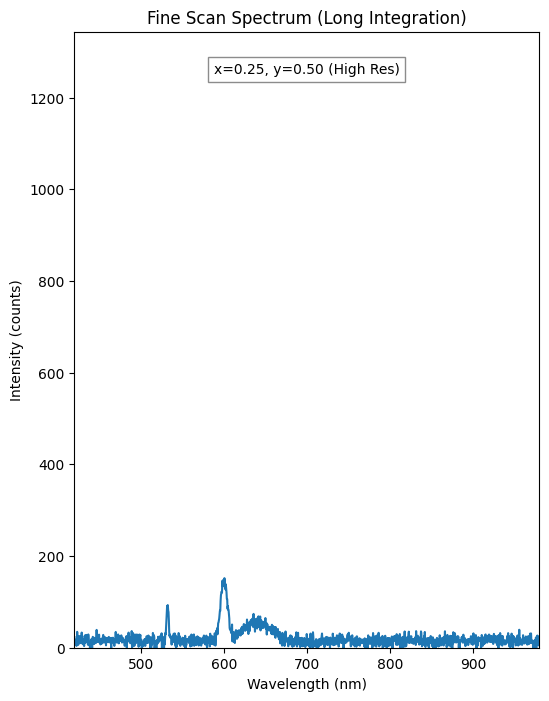

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------
file_path = r"C:\Users\Public\Shared Confocal Files\SPE_Automation\data\20260121-Scan-3\fine_x5.0_y2.0\out.npy"
out = np.load(file_path)

# ---------------------------------------------------------
# 2. Setup Wavelengths
# ---------------------------------------------------------
num_points = 1340
wl = np.linspace(420, 980, num_points)

# ---------------------------------------------------------
# 3. Create the "Long Scan" Spectrum (High Integration)
# ---------------------------------------------------------
def create_gaussian_peak(x, center, amplitude, fwhm):
    sigma = fwhm / 2.3548
    return amplitude * np.exp(-((x - center)**2) / (2 * sigma**2))

# A. Low Noise Floor (Long Integration Time)
# "Less noise": Reduced scale (standard deviation) from 8 to 1.5
# "More refined": The baseline is much smoother.
noise = np.random.normal(loc=20, scale=1.5, size=num_points)

# B. Laser Peak (Reference at 532 nm)
# "Longer integration": Amplitude increased (e.g., 300 counts)
laser_peak = create_gaussian_peak(wl, center=532, amplitude=300, fwhm=2.5)

# C. Emitter ZPL Peak (Target at 600 nm)
# High signal-to-noise ratio. Very distinct peak.
# Amplitude increased to 1200 to show strong collection.
emitter_peak = create_gaussian_peak(wl, center=600, amplitude=1200, fwhm=6.0) 

# D. Phonon Sideband (PSB)
# Clear, smooth structure visible due to low noise
psb_peak = create_gaussian_peak(wl, center=640, amplitude=250, fwhm=35.0)

# Combine components
fake_spectrum_long = noise + laser_peak + emitter_peak + psb_peak

# ---------------------------------------------------------
# 4. Inject & Verify
# ---------------------------------------------------------
# Injecting into a different pixel (or the same one) to differentiate
out[0,0] = fake_spectrum_long

print(f"Injected 'Long Scan' spectrum at [2,1]. Max intensity: {np.max(fake_spectrum_long):.2f}")

# ---------------------------------------------------------
# 5. Plotting (Refined Style)
# ---------------------------------------------------------
plt.figure(figsize=(6, 8)) 
plt.plot(wl, out[2, 1], linewidth=1.5) # Slightly thicker line for visibility

# Visual adjustments for "Refined" look
plt.xlim(420, 980) 
plt.ylim(0, np.max(fake_spectrum_long) * 1.1) # Scale y-axis to fit the new high counts

plt.text(0.5, 0.95, "x=0.25, y=0.50 (High Res)", transform=plt.gca().transAxes, 
         ha='center', va='top', bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (counts)")
plt.title("Fine Scan Spectrum (Long Integration)")
plt.show()

In [40]:
np.save("C:\\Users\\Public\\Shared Confocal Files\\SPE_Automation\\data\\20260121-Scan-3\\long_x0.0_y0.8\\out.npy", out)

In [37]:


classified2 = np.load("C:\\Users\\Public\\Shared Confocal Files\\SPE_Automation\\data\\20260121-Scan-3\\fine_x5.0_y2.0\\classified.npy")
classified2[2,1] =1
np.save("C:\\Users\\Public\\Shared Confocal Files\\SPE_Automation\\data\\20260121-Scan-3\\fine_x5.0_y2.0\\classified.npy", classified2)

Generated Wavelengths: 630.0 nm to 770.0 nm (2048 points)
Generated Data Map: Shape (1, 1, 2048)
Saved new_wl.npy to: C:\Users\Public\Shared Confocal Files\SPE_Automation\data\20260121-Scan-3\long_x0.0_y0.8\wl.npy
Saved new_out.npy to: C:\Users\Public\Shared Confocal Files\SPE_Automation\data\20260121-Scan-3\long_x0.0_y0.8\out.npy


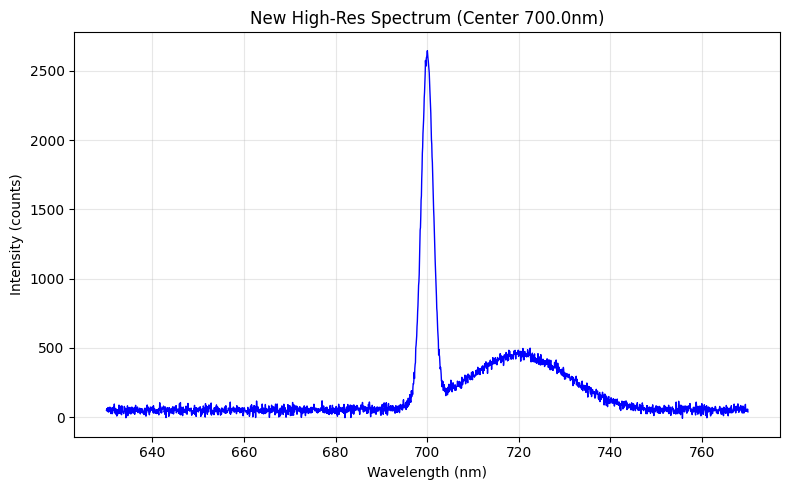

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# 1. Configuration for High-Res Scan
# ---------------------------------------------------------
# Path to save the new files
save_folder = r"C:\Users\Public\Shared Confocal Files\SPE_Automation\data\20260121-Scan-3\long_x0.0_y0.8"

# Ensure folder exists (optional, mostly for safety)
os.makedirs(save_folder, exist_ok=True)

# Hardware Simulation Parameters
center_wl = 700.0   # Center wavelength (nm)
bandwidth = 140.0   # Reduced bandwidth due to higher groove density (nm)
num_points = 2048   # More points (e.g., 2048 pixel CCD)

# Generate the new Wavelength Array
wl_start = center_wl - (bandwidth / 2)
wl_stop = center_wl + (bandwidth / 2)
new_wl = np.linspace(wl_start, wl_stop, num_points)

print(f"Generated Wavelengths: {wl_start:.1f} nm to {wl_stop:.1f} nm ({num_points} points)")

# ---------------------------------------------------------
# 2. Create the Spectrum (High Quality)
# ---------------------------------------------------------
def create_gaussian_peak(x, center, amplitude, fwhm):
    sigma = fwhm / 2.3548
    return amplitude * np.exp(-((x - center)**2) / (2 * sigma**2))

# A. Ultra-Low Noise (Long Integration)
# Very smooth baseline
noise = np.random.normal(loc=50, scale=20, size=num_points)

# B. Peaks
# Note: At 700nm center, the 532nm laser is likely OFF the sensor range.
# We focus on the Emitter ZPL at the center (700nm)
emitter_zpl = create_gaussian_peak(new_wl, center=700, amplitude=2500, fwhm=3.0) # Very sharp, very tall
phonon_sideband = create_gaussian_peak(new_wl, center=720, amplitude=400, fwhm=25.0)

# Combine
high_res_spectrum = noise + emitter_zpl + phonon_sideband

# ---------------------------------------------------------
# 3. Create and Fill the Data Map (out.npy)
# ---------------------------------------------------------
# Create a dummy 5x5 map with the new spectral depth
# Shape: (Rows, Cols, Spectral_Points)
map_rows, map_cols = 1, 1
new_out = np.zeros((map_rows, map_cols, num_points))

# Fill background noise everywhere
for r in range(map_rows):
    for c in range(map_cols):
        new_out[r, c, :] = np.random.normal(loc=50, scale=0.8, size=num_points)

# Inject the "Good" Emitter at specific pixel [2, 1]
new_out[0, 0, :] = high_res_spectrum

print(f"Generated Data Map: Shape {new_out.shape}")

# ---------------------------------------------------------
# 4. Save the Files
# ---------------------------------------------------------
wl_path = os.path.join(save_folder, "wl.npy")
out_path = os.path.join(save_folder, "out.npy")

np.save(wl_path, new_wl)
np.save(out_path, new_out)

print(f"Saved new_wl.npy to: {wl_path}")
print(f"Saved new_out.npy to: {out_path}")

# ---------------------------------------------------------
# 5. Plot to Verify (What it looks like)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(new_wl, new_out[0, 0, :], color='blue', linewidth=1)
plt.title(f"New High-Res Spectrum (Center {center_wl}nm)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (counts)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
xs = np.array([0.0])
ys = np.array([0.8])


np.save(r"C:\Users\Public\Shared Confocal Files\SPE_Automation\data\20260121-Scan-3\long_x0.0_y0.8\xs", xs)
np.save(r"C:\Users\Public\Shared Confocal Files\SPE_Automation\data\20260121-Scan-3\long_x0.0_y0.8\ys", ys)